In [223]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Importing libraries

In [224]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp
import xplt


import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [225]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')



plt.ion()

p = 400.0  # beam momentum (GeV/c)
momentum = p  # beam momentum (GeV/c)
Brho = p * 3.3356  # beam rigidity ???

N_EX = 10e-6
N_EY = 5e-6


In [226]:
# Proton mass in GeV/c^2
proton_mass_GeV = xt.PROTON_MASS_EV * 1e-9

# Beam energy in GeV
beam_energy_GeV = 400

# Compute gamma
gamma = beam_energy_GeV / proton_mass_GeV
print(f"Gamma: {gamma}")

Gamma: 426.3155693395322


In [227]:
EX = N_EX / gamma
EY = N_EY / gamma
print(f"EX: {EX}")

EX: 2.3456802235706435e-08


In [228]:
deltaP_P = 1.5e-3
print(f"deltaP_P: {deltaP_P}")

deltaP_P: 0.0015


In [229]:
# TECA DEFINITION

TECA = xc.EverestCrystal(
    length=2e-3, 
    material=xc.materials.SiliconCrystal, 
    bending_angle = 174e-6 ,
    side="left",
    lattice="strip",
    jaw = - 52.4e-3,
    tilt = - 1.23e-3,
    width = 1.8e-3,
    height = 50e-3
    )

TECS = xc.EverestCrystal(
    length=2e-3, 
    material=xc.materials.SiliconCrystal, 
    bending_angle = 174e-6 ,
    side="left",
    lattice="strip",
    jaw = -0.0315,
    tilt = 10e-6,
    width = 2e-3,
    height = 50e-3
    )

# Given values
x_teca = TECA.jaw  
delta_x_teca_prime = TECA.tilt + TECA.bending_angle 

In [230]:
class SeptumInteraction:
    def __init__(self, blade_position: float = 68e-3, thickness:float = 0.3e-3, kick:float = 1e-3) -> None:
        self.blade_position = blade_position
        self.thickness = thickness
        self.kick = kick
        pass

    def interact(self, particles: xp.Particles) -> t.Optional[t.Dict]:
        n_part = particles._num_active_particles

        # lose the particles on the blade
        particles.state[:n_part] = np.where((particles.x[:n_part] > self.blade_position) & (particles.x[:n_part] < (self.blade_position + self.thickness)) & (particles.state[:n_part]==1), -1, 1)

        # kick the particles beyond the blade
        if self.kick != 0:
            particles.px[:n_part] +=  np.where((particles.x[:n_part] > (self.blade_position + self.thickness)) & (particles.state[:n_part]==1), 1, 0) * self.kick

        return None


In [231]:
# install the 5 zs
def install_septa(line, install_zs=True, septum_aperture_size=68e-3):#
    septa_names_with_apertures = []

    if install_zs:
        septum_names = ["zs.21633", "zs.21639", "zs.21655", "zs.21671", "zs.21676"]
        
        for septum_name in septum_names:
            zs = xt.BeamInteraction(
                length=0.0,
                interaction_process=SeptumInteraction(
                    blade_position=septum_aperture_size, thickness=0.6e-3, kick=0.440e-3 / 5
                ),
            )
            line.insert_element(septum_name + ".sep", zs, index=septum_name)
            septa_names_with_apertures.append(septum_name + ".sep")
        
    tpst = xt.BeamInteraction(
                length=0.0,
                interaction_process=SeptumInteraction(
                    blade_position=0.04, thickness=0.01, kick=0
                ))
    line.insert_element("tpst.21760_entry" + ".sep", tpst, index="tpst.21760_entry")
    septa_names_with_apertures.append("tpst.21760_entry" + ".sep")


    for mst in ["mst.21774", "mst.21779", "mst.21794"]:
        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=5.2e-3, kick=1.69520713e-3 / 3
            ),
        )
        line.insert_element(mst + ".sep", zs, index=mst)
        septa_names_with_apertures.append(mst + ".sep")

    for mse in ["mse.21832", "mse.21837", "mse.21852", "mse.21857", "mse.21872"]:
        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=20e-3, kick=9.74519477e-3 / 5
            ),
        )
        line.insert_element(mse + ".sep", zs, index=mse)
        septa_names_with_apertures.append(mse + ".sep")

    septum = xt.LimitRect(min_x=-1.0, max_x=septum_aperture_size, min_y=-1.0, max_y=1.0)


    line.insert_element(
        name="tt20.extraction",
        element=xt.LimitRect(min_x=-1.0, max_x=70e-3, min_y=-1.0, max_y=1.0),
        index="ap.do.mse21872",
    )
    return septa_names_with_apertures


In [232]:
def match_tunes(line, qx, qy):
    # Extraction tunes
    opt = line.match(solve=False,
                     method='4d',
        vary=[
            xt.VaryList(['kqf', 'kqd'], step=1e-7),   # Varying quadrupole focal strengths
            xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4),   # Varying phase values
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-5),# Desired target tunes
            #xt.TargetSet(dqx=-1 * qx, dqy=0.47 * qy, tol=1e-3),   # Desired target chromaticities
        ])
    return opt

In [233]:
def match_chromaticity(line, qx, qy):
    # Extraction tunes
    opt = line.match(solve=False,
                     method='4d',
        vary=[
            xt.VaryList(['klsfa', 'klsda', 'klsdb', 'klsfb'], step=1e-7),   # Varying setupoles strengths ,  klsfa, klsda, klsfb, klsdb????
        ],
        targets=[
            xt.TargetSet(dqx=-1 * int(qx), dqy = 0.47 * int(qy), tol=1e-3),   # Desired target chromaticities
        ])
    return opt

## Uploading the line from Q22

In [234]:
line = xt.Line.from_json("../database/lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
#line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )

line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = line.get_table()['s', 'TECA.entry']


septa_names_with_apertures = install_septa(line, install_zs=False)
line.cycle("TECA.entry", inplace=True)


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

<Line  at 4842016144>

### Computing twiss parameters and other properties from this optics

In [235]:
tw_init = line.twiss(method='4d')
print(tw_init.qx)
print(tw_init.qy)

tw0 = tw_init.to_pandas()
tw0.index = tw0.name  

The line has collective elements.
In the twiss computation collective elements are replaced by drifts
22.13000000010263
22.180000000010537


In [236]:
betx_teca = tw0.loc['TECA.entry'].betx
dx_teca = tw0.loc['TECA.entry'].dx

# COMPUTING THE BEAM SIZE 
tw0['sx_mm'] = np.sqrt(tw0['betx'] * EX + (tw0['dx'] * deltaP_P)**2) * 1e3
tw0['sy_mm'] = np.sqrt(tw0['bety'] * EY + (tw0['dy'] * deltaP_P)**2) * 1e3
    
B_term0 = betx_teca * EX
D_term0 = (dx_teca * deltaP_P)**2
ratio0 = D_term0 / B_term0

print(f'D term / B term = {ratio0:.2f}')
print(f"sigma_x max = {tw0.sx_mm.max()} mm")
print(f"sigma_y max = {tw0.sy_mm.max()} mm")

D term / B term = 3.31
sigma_x max = 10.468444863433009 mm
sigma_y max = 1.1036200168346404 mm


In [237]:
mu_x_teca = tw0.loc['TECA.entry'].mux
mu_x_tpst = tw0.loc['tpst.21760_entry'].mux
mu_x_tcsm = tw0.loc['tcsm.51932.'].mux

phaseAdvanceTecaTpst = mu_x_tpst - mu_x_teca
phaseAdvanceTecaTcsm = mu_x_tcsm - mu_x_teca
phaseAdvanceTpstTcsm = mu_x_tcsm - mu_x_tpst

print(f"Phase advance Teca - Tpst: {phaseAdvanceTecaTpst:.2f}")
print(f"Phase advance Teca - Tcsm: {phaseAdvanceTecaTcsm:.2f}")
print(f"Phase advance Tpst - Tcsm: {phaseAdvanceTpstTcsm:.2f}")

Phase advance Teca - Tpst: 14.74
Phase advance Teca - Tcsm: 3.83
Phase advance Tpst - Tcsm: -10.91


In [238]:
# Get the positions of the TECA and COLLIMATORS markers
teca_position = line.get_table()['s', 'TECA.entry']
tpst_position = line.get_table()['s', 'tpst.21760_entry']
tcsm_position = line.get_table()['s', 'tcsm.51932.']


## Choosing the tune

In [239]:
tune = 23.02

# Switching to desired tune and modifying the apertures

In [240]:
optTune = match_tunes(line, tune, tune + 0.05)
optChromaticity = match_chromaticity(line, tune, tune + 0.05)

optTune.step(10)
optTune.target_status()
optTune.vary_status()

# CHanging the chromaticity afterwards
optChromaticity.step(10)

optChromaticity.target_status()
optChromaticity.vary_status() 

The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
                                             
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
Optimize - start penalty: 12.59     

Changing the apertures of the elements to let the beam pass

In [241]:
# Iterate through all elements in the line
for element_name, element in line.element_dict.items():
    # Check if the element is of type LimitEllipse
    if isinstance(element, xt.LimitEllipse):
        print(f"Element Name: {element_name}, Element: {element}")
        element.a = 1
        element.b = 1
        
# Iterate through all elements in the line
for element_name, element in line.element_dict.items():
    # Check if the element is of type LimitRect
    if isinstance(element, xt.LimitRect):
        print(f"Element Name: {element_name}, Element: {element}")
        element.min_x = -1
        element.max_x = 1

Element Name: qe.11402_aper, Element: LimitEllipse(a=0.076, b=0.0192)
Element Name: qd.11710_aper, Element: LimitEllipse(a=0.0415, b=0.0415)
Element Name: qf.11810_aper, Element: LimitEllipse(a=0.076, b=0.0192)
Element Name: qfa.21610_aper, Element: LimitEllipse(a=0.106, b=0.0203)
Element Name: qfa.21810_aper, Element: LimitEllipse(a=0.106, b=0.0203)
Element Name: qe.30202_aper, Element: LimitEllipse(a=0.076, b=0.0192)
Element Name: qecd.30602_aper, Element: LimitEllipse(a=0.076, b=0.0192)
Element Name: qecd.31402_aper, Element: LimitEllipse(a=0.076, b=0.0192)
Element Name: ap.up.vvsb_aper, Element: LimitEllipse(a=0.156, b=0.156)
Element Name: ap.do.vvsb_aper, Element: LimitEllipse(a=0.156, b=0.156)
Element Name: ap.up.coldex_aper, Element: LimitEllipse(a=0.0335, b=0.0335)
Element Name: ap.do.coldex_aper, Element: LimitEllipse(a=0.0335, b=0.0335)
Element Name: qfa.41810_aper, Element: LimitEllipse(a=0.106, b=0.0203)
Element Name: qe.50202_aper, Element: LimitEllipse(a=0.076, b=0.0192)


### Changing the tpst blade position to block the non-channeled particles

In [242]:
element_name = 'tpst.21760_entry.sep'
element = line[element_name]

print(f"Element Name: {element_name}")
print(f"Type: {type(element)}")
print(f"Length: {element.length}")
print(f"Blade Position: {element.interaction_process.blade_position}")
print(f"Thickness: {element.interaction_process.thickness}")
print(f"Kick: {element.interaction_process.kick}")


# MOVING THE BLADE UP OR DOWN
element.interaction_process.blade_position = 0.03
print(f"Updated Blade Position: {element.interaction_process.blade_position}")

Element Name: tpst.21760_entry.sep
Type: <class 'xdeps.madxutils.View'>
Length: 0.0
Blade Position: 0.04
Thickness: 0.01
Kick: 0
Updated Blade Position: 0.03


# Tracking channeled particles

The particles are initialised with a px equal to the tilt of the crystal plus it's bending angle

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


Slicing line:   0%|          | 0/4614 [00:00<?, ?it/s]

Particle lost at turn 0


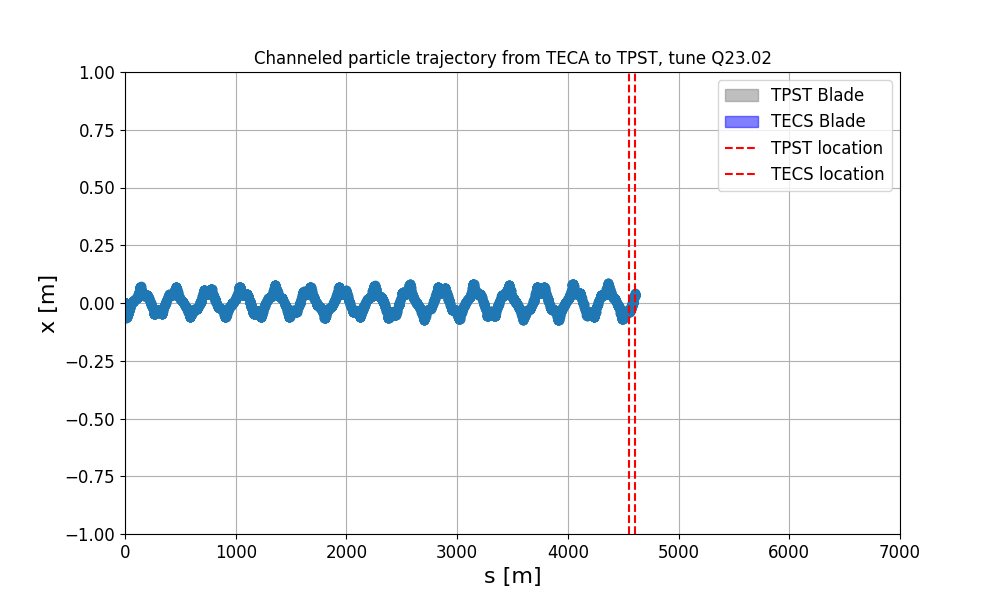

In [243]:
tw = line.twiss(method='4d')

line.discard_tracker()
line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )
line.build_tracker()

# Initialize a single particle at TECA location
particles = line.build_particles(
        method='4d',
        x = TECA.jaw,
        px = TECA.tilt + TECA.bending_angle,                    # THE BENDING ANGLE INDICATES THAT THE PARTICLE IS CHANNELED
        y = 0,
        py = 0,
        zeta = 0,
        delta = deltaP_P,
        mass0 = xt.PROTON_MASS_EV,
        p0c = 400e9
    )

# Track particles for N turns and store positions
num_turns = 100
line.track(
        particles,
        num_turns=1,
        turn_by_turn_monitor="ONE_TURN_EBE",
    )
    

    # Check if the particle is lost during the tracking
if np.any(particles.state < 1):
    lost_turn = np.where(particles.state < 1)[0][0]
    print(f"Particle lost at turn {lost_turn}")
else:
    print("Particle not lost during the tracking")
    
    
# Plot the phase space at TECA location
plt.figure(figsize=(10, 6))
#plt.plot(line.record_last_track.x, line.record_last_track.px, 'o')
plt.plot(line.record_last_track.s[0], line.record_last_track.x[0], 'o')

#plt.xlabel('x [m]')
plt.xlabel('s [m]')

#plt.ylabel('px [rad]')
plt.ylabel('x [m]')

plt.title(f'Channeled particle trajectory from TECA to TPST, tune Q{tune}')
plt.grid(True)

# Draw a rectangle at the TPST entry location
tpst = plt.Rectangle((tpst_position, element.interaction_process.blade_position), 
                     width=2, height=element.interaction_process.thickness, 
                     color='grey', alpha=0.5, label='TPST Blade')
plt.gca().add_patch(tpst)

tecs_position = line.get_table()['s', 'TECS.everest_crystal']
tecs = plt.Rectangle((tecs_position, TECS.jaw), 
                     width=TECA.length, height=TECA.width, 
                     color='blue', alpha=0.5, label='TECS Blade')
plt.gca().add_patch(tecs)

plt.ylim(-1, 1)
plt.xlim(0, 7000)
#plt.ylim(-0.1, 0.1)
#plt.xlim(4520, 4620)

plt.axvline(x=tpst_position, color='r', linestyle='--', label='TPST location')
plt.axvline(x=tecs_position, color='r', linestyle='--', label='TECS location')


plt.legend()

In [244]:
recordChanneled = line.record_last_track
# Extract the s and x values from the record
s_valuesChanneled = recordChanneled.data.s
x_valuesChanneled = recordChanneled.data.x



# Find the index of the tpst location in the s_values array using np.isclose
tpst_index = np.where(np.isclose(s_valuesChanneled, tpst_position))[0][0]

# Get the x value at the tpst location
x_tpstChanneled = x_valuesChanneled[tpst_index]

print(f"x at TPST location: {x_tpstChanneled}")




x at TPST location: 0.02927267300716862


## Tracking the non channeled particles


In [245]:
line = xt.Line.from_json("../database/lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
#line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )

line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = line.get_table()['s', 'TECA.entry']


septa_names_with_apertures = install_septa(line, install_zs=False)
line.cycle("TECA.entry", inplace=True)

optTune = match_tunes(line, tune, tune + 0.05)
optChromaticity = match_chromaticity(line, tune, tune + 0.05)

# Optimisers for tune
optTune.step(10)
optTune.target_status()
optTune.vary_status()

# Optimisers for chromaticity
optChromaticity.step(10)
optChromaticity.target_status()
optChromaticity.vary_status() 



# Iterate through all elements in the line
for element_name, element in line.element_dict.items():
    # Check if the element is of type LimitEllipse
    if isinstance(element, xt.LimitEllipse):
        print(f"Element Name: {element_name}, Element: {element}")
        element.a = 1
        element.b = 1
        
# Iterate through all elements in the line
for element_name, element in line.element_dict.items():
    # Check if the element is of type LimitRect
    if isinstance(element, xt.LimitRect):
        print(f"Element Name: {element_name}, Element: {element}")
        element.min_x = -1
        element.max_x = 1
        
        
element_name = 'tpst.21760_entry.sep'
element = line[element_name]

print(f"Element Name: {element_name}")
print(f"Type: {type(element)}")
print(f"Length: {element.length}")
print(f"Blade Position: {element.interaction_process.blade_position}")
print(f"Thickness: {element.interaction_process.thickness}")
print(f"Kick: {element.interaction_process.kick}")


# MOVING THE BLADE UP OR DOWN
element.interaction_process.blade_position = 0.03
print(f"Updated Blade Position: {element.interaction_process.blade_position}")

Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
                                             
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
Optimize - start penalty: 12.59     

Creating the particles with a px equal to the tilt of the crystal (non channeled)

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


Slicing line:   0%|          | 0/4614 [00:00<?, ?it/s]

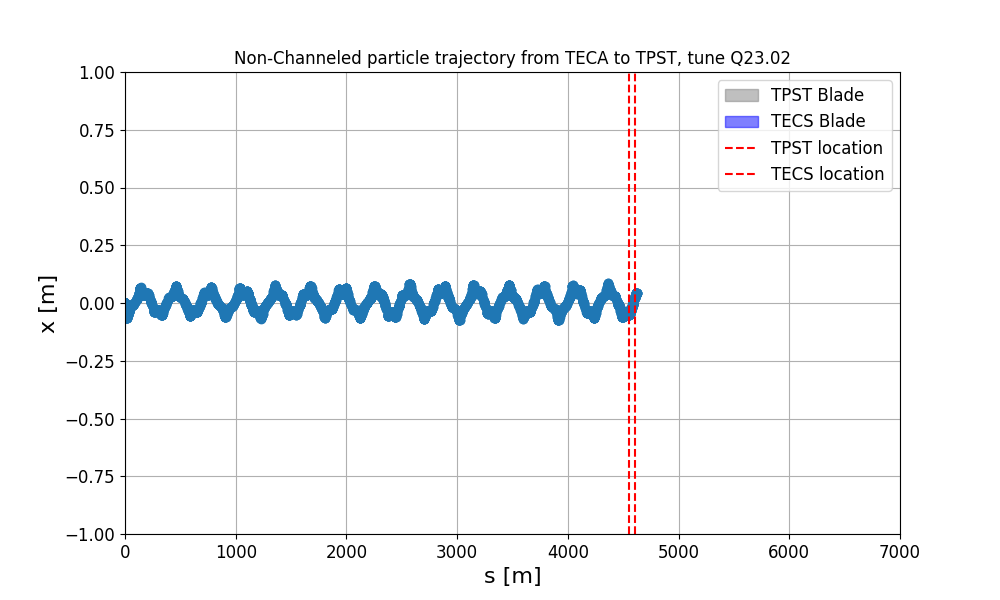

In [246]:
tw = line.twiss(method='4d')

line.discard_tracker()
line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )
line.build_tracker()



# Initialize a single particle at TECA location
particles = line.build_particles(
        method='4d',
        x = TECA.jaw,
        px = TECA.tilt,                    # THE BENDING ANGLE INDICATES THAT THE PARTICLE IS CHANNELED
        y = 0,
        py = 0,
        zeta = 0,
        delta = deltaP_P,
        mass0 = xt.PROTON_MASS_EV,
        p0c = 400e9
    )

# Track particles for N turns and store positions
num_turns = 100
line.track(
        particles,
        num_turns=1,
        turn_by_turn_monitor="ONE_TURN_EBE",
    )
    
# Plot the phase space at TECA location
plt.figure(figsize=(10, 6))
#plt.plot(line.record_last_track.x, line.record_last_track.px, 'o')
plt.plot(line.record_last_track.s[0], line.record_last_track.x[0], 'o')

#plt.xlabel('x [m]')
plt.xlabel('s [m]')

#plt.ylabel('px [rad]')
plt.ylabel('x [m]')
plt.ylim(-1, 1)
plt.xlim(0, 7000)
#plt.ylim(-0.1, 0.1)
#plt.xlim(4520, 4620)

plt.title(f'Non-Channeled particle trajectory from TECA to TPST, tune Q{tune}')
plt.grid(True)

# Draw a rectangle at the TPST entry location
tpst = plt.Rectangle((tpst_position, element.interaction_process.blade_position), 
                     width=2, height=element.interaction_process.thickness, 
                     color='grey', alpha=0.5, label='TPST Blade')
plt.gca().add_patch(tpst)


tecs_position = line.get_table()['s', 'TECS.everest_crystal']
tecs = plt.Rectangle((tecs_position, TECS.jaw), 
                     width=TECA.length, height=TECA.width, 
                     color='blue', alpha=0.5, label='TECS Blade')
plt.gca().add_patch(tecs)

plt.axvline(x=tpst_position, color='r', linestyle='--', label='TPST location')
plt.axvline(x=tecs_position, color='r', linestyle='--', label='TECS location')

plt.legend()


In [247]:
recordNONChanneled = line.record_last_track
# Extract the s and x values from the record
s_valuesNONChanneled = recordNONChanneled.data.s
x_valuesNONChanneled = recordNONChanneled.data.x


# Find the index of the tpst location in the s_values array using np.isclose
tpst_index = np.where(np.isclose(s_valuesNONChanneled, tpst_position))[0][0]

# Get the x value at the tpst location
x_tpstNONChanneled = x_valuesNONChanneled[tpst_index]

print(f"x at TPST location: {x_tpstNONChanneled}")


x at TPST location: 0.020165361531907428


## Double check the aperture given by the channeling at the TPST 


In [248]:
from IPython.display import display, Math

print(f"TECA position: {teca_position}")
print(f"TPST position: {tpst_position}")
print(f"Horizontal osition at tpst for channeled particles: {x_tpstChanneled}")
print(f"Horizontal osition at tpst for non-channeled particles: {x_tpstNONChanneled}")


display(Math(r"\Delta x = {:.2f} \, \text{{mm}}".format((x_tpstChanneled - x_tpstNONChanneled) * 1e3)))

TECA position: 0.0
TPST position: 4602.830199999884
Horizontal osition at tpst for channeled particles: 0.02927267300716862
Horizontal osition at tpst for non-channeled particles: 0.020165361531907428


<IPython.core.display.Math object>

# Multiturn study for same optics

In [249]:
line = xt.Line.from_json("../database/lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)



line.discard_tracker()
# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
#line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )
line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = line.get_table()['s', 'TECA.entry']


septa_names_with_apertures = install_septa(line, install_zs=False)
line.cycle("TECA.entry", inplace=True)

optTune = match_tunes(line, tune, tune + 0.05)
optChromaticity = match_chromaticity(line, tune, tune + 0.05)

# Optimisers for tune
optTune.step(10)
optTune.target_status()
optTune.vary_status()

# Optimisers for chromaticity
optChromaticity.step(10)
optChromaticity.target_status()
optChromaticity.vary_status() 




# Iterate through all elements in the line
for element_name, element in line.element_dict.items():
    # Check if the element is of type LimitEllipse
    if isinstance(element, xt.LimitEllipse):
        print(f"Element Name: {element_name}, Element: {element}")
        element.a = 1
        element.b = 1
        
# Iterate through all elements in the line
for element_name, element in line.element_dict.items():
    # Check if the element is of type LimitRect
    if isinstance(element, xt.LimitRect):
        print(f"Element Name: {element_name}, Element: {element}")
        element.min_x = -1
        element.max_x = 1
        
        
element_name = 'tpst.21760_entry.sep'
element = line[element_name]

print(f"Element Name: {element_name}")
print(f"Type: {type(element)}")
print(f"Length: {element.length}")
print(f"Blade Position: {element.interaction_process.blade_position}")
print(f"Thickness: {element.interaction_process.thickness}")
print(f"Kick: {element.interaction_process.kick}")


# MOVING THE BLADE UP OR DOWN
element.interaction_process.blade_position = 0.03
print(f"Updated Blade Position: {element.interaction_process.blade_position}")

Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
                                             
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
Optimize - start penalty: 12.59     

In [250]:
tw_table = line.twiss(method='4d', x = TECA.jaw, px = TECA.tilt)


tw = line.twiss(method='4d', x = TECA.jaw, px = TECA.tilt)
tw = tw.to_pandas()
tw.index = tw.name

The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts


In [251]:
# Initialize an empty DataFrame to store Twiss parameters
twiss_df = pd.DataFrame()

In [252]:
print([0,10])

[0, 10]


In [253]:

# Loop over the range of tunes
for N in range(11):
    
        
    beta_x_at_teca = tw.loc['TECA.entry'].betx
    beta_tpst = tw.loc['tpst.21760_entry'].betx
    alpha_teca = tw.loc['TECA.entry'].alfx                 #ALPHA X AT TECA
    
    
    # Get the phase advances at the positions of the TECA and TPST markers
    mu_x_teca = tw.loc['TECA.entry'].mux
    mu_x_tpst = tw.loc['tpst.21760_entry'].mux
    mu_x_tcsm = tw.loc['tcsm.51932.'].mux

    # Calculate the phase advance between the TECA and TPST markers
    delta_mu_xtpst = ((mu_x_tpst - mu_x_teca)) * 2 * np.pi
    # Calculate the phase advance between the TECA and TCMS markers
    delta_mu_x_tcsm = ((mu_x_tcsm - mu_x_teca)) * 2 * np.pi
    # Calculate the phase advance between the TPST and TCMS markers
    delta_mu_TCSM_TPST = ((mu_x_tcsm - mu_x_tpst)) * 2 * np.pi
    
    # RETREIVING THE EVOLUTION MATRIX FROM TECA FROM TWISS TABLE
    # Define number of turns (adjust N as needed)
    #N = number of turns
    # Compute the transfer matrix for one full turn from TECA.entry to itself
    full_turn_matrix = tw_table.get_R_matrix(start='TECA.entry', end='_end_point')
    # Compute the full turn matrix exponentiated to N turns
    full_turn_matrix_N = np.linalg.matrix_power(full_turn_matrix, N)
    # Compute the transport matrix from TECA to TPST
    Half_turn_matrix = tw_table.get_R_matrix(start='TECA.entry', end='tpst.21760_entry')
    # Compute the overall transport matrix for N turns plus transport to TPST
    multi_turn_to_tpst = full_turn_matrix_N @ Half_turn_matrix

    phaseAdvanceTecaTpst = delta_mu_xtpst  + N * tune * 2 * np.pi # phase advance between TECA and TPST for more than half a turn (N)

    # tw['delta_x'] = multi_turn_to_tpst[0, 1] * TECA.bending_angle
    tw['delta_x'] = np.sqrt(betx_teca * beta_tpst) * np.sin(phaseAdvanceTecaTpst) * TECA.bending_angle
    tw['xcol'] = multi_turn_to_tpst[0, 0] * (TECA.jaw + TECA.width / 2) + multi_turn_to_tpst[0, 1] * TECA.tilt
     # THIS WILL CHANGE WHEN WE SET THE BUMP TO GET THE BEAM CLOSE TO THE CRYSTAL
    


    
    
                                                                    # x AT TPST 
    #####################################################################
    #x_NONchanneledTPST = np.sqrt(beta_tpst/beta_x_at_teca) * (np.cos(delta_mu_xtpst) + alpha_teca * np.sin(delta_mu_xtpst)) * (TECA.jaw + TECA.width) + np.sqrt(beta_tpst*beta_x_at_teca) *  np.sin(delta_mu_xtpst) * TECA.tilt   # ANALITIC FORMULAE FOR PERIODIC LATTICES
    x_NONchanneledTPST = tw.loc['tpst.21760_entry'].xcol
    
                                                                            # DIFFERENCE BETWEEN CHANNELED AND NON CHANNELED PARTICLES POSITION AT THE COLLIMATORS Computing the \delta_x at the TECA and TCMS taking only into account the channeling effect 
    ######################################################################
    #EasyDeltaXtpst = np.sqrt(beta_x_at_teca * beta_tpst) * np.sin(delta_mu_xtpst) * TECA.bending_angle
    EasyDeltaXtpst = tw.loc['tpst.21760_entry'].delta_x
    ErrorEasyDeltaXtpst = np.sqrt(beta_tpst/beta_x_at_teca) * (np.cos(delta_mu_xtpst) + alpha_teca * np.sin(delta_mu_xtpst)) * (TECA.width)
    
    turn = N
    
    variable_names = [
        "turn",
        "beta_x_at_teca", "alpha_teca",
        "beta_tpst",
        "mu_x_teca", "mu_x_tpst", "delta_mu_xtpst",
        "EasyDeltaXtpst", 
        "ErrorEasyDeltaXtpst", 
        "x_NONchanneledTPST", "phaseAdvanceTecaTpst"
    ]

    variable_values = [
        turn,
        beta_x_at_teca, alpha_teca,
        beta_tpst,
        mu_x_teca, mu_x_tpst, delta_mu_xtpst,
        EasyDeltaXtpst, 
        ErrorEasyDeltaXtpst, 
        x_NONchanneledTPST, phaseAdvanceTecaTpst
    ]
    
    # Append the results to the DataFrame
    twiss_df = pd.concat([twiss_df, pd.DataFrame([variable_values], columns=variable_names)], ignore_index=True)

twiss_df = twiss_df.drop_duplicates(subset='turn')

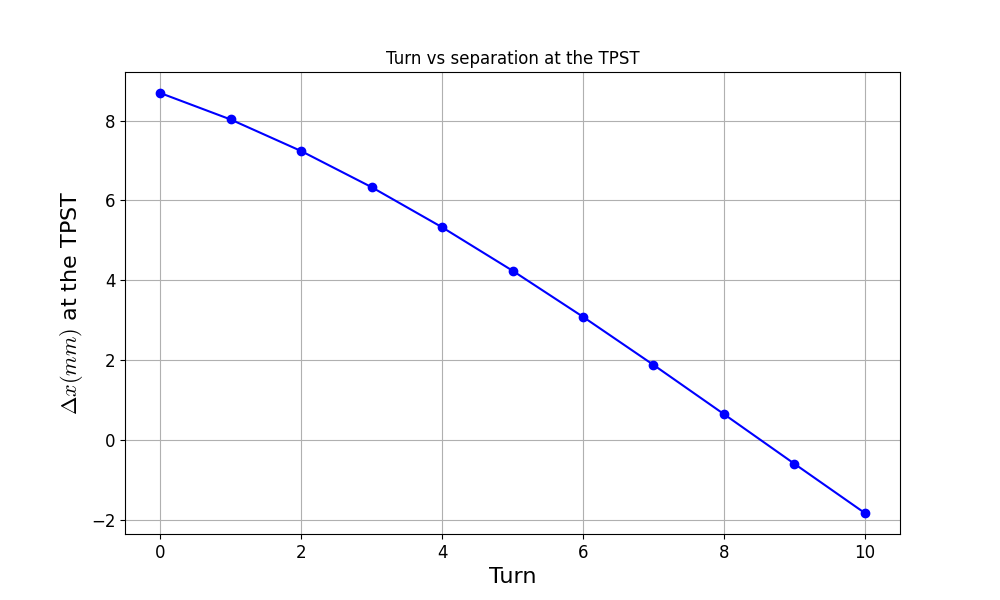

In [254]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(twiss_df['turn'], twiss_df['EasyDeltaXtpst']*1000, marker='o', linestyle='-', color='b')
plt.xlabel('Turn')
plt.ylabel(r"$\Delta x (mm)$ at the TPST")
plt.title('Turn vs separation at the TPST')
plt.grid(True)
plt.show()

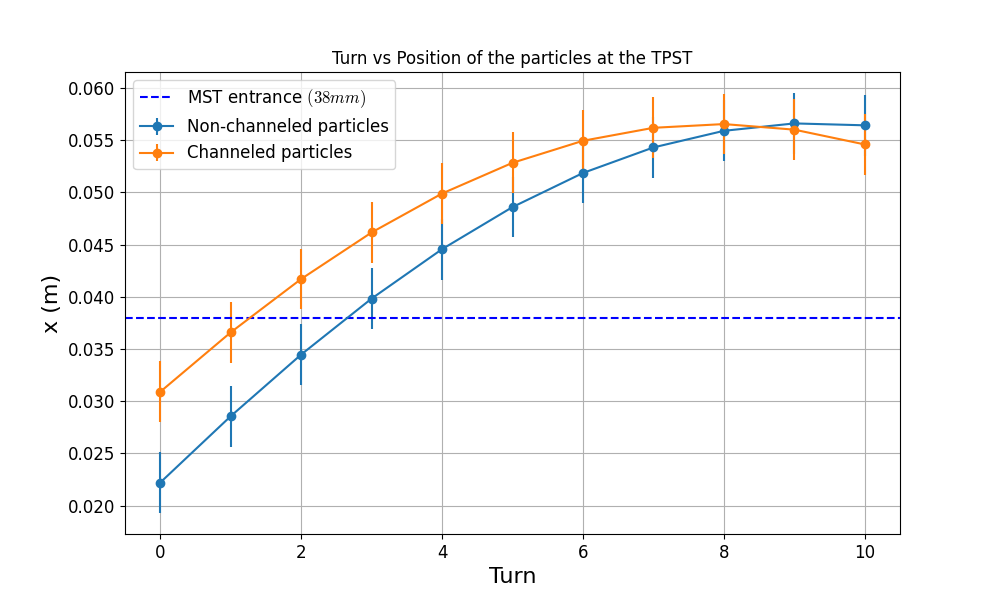

In [255]:

plt.figure(figsize=(10, 6))
#error = np.abs(ErrorEasyDeltaXtpst)
plt.errorbar(twiss_df['turn'], twiss_df['x_NONchanneledTPST'] , yerr = np.abs(twiss_df["ErrorEasyDeltaXtpst"]), fmt='o-', label='Non-channeled particles')
plt.errorbar(twiss_df['turn'], twiss_df['x_NONchanneledTPST'] +  twiss_df["EasyDeltaXtpst"], yerr = np.abs(twiss_df["ErrorEasyDeltaXtpst"]), fmt='o-', label='Channeled particles')


plt.axhline(0.038, color='b', linestyle='--', label=r'MST entrance $ (38 mm )$')
plt.xlabel('Turn')
plt.ylabel('x (m)')
plt.title('Turn vs Position of the particles at the TPST')
plt.legend()
plt.grid(True)
plt.show()